# **WINE QUALITY**

### **Library**

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

### **Dataset**

In [20]:
df_train = pd.read_csv('/content/data_training.csv')
df_test = pd.read_csv('/content/data_testing.csv')
df_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


### **Informasi Dataset**

In [21]:
print("--- Info Dataset Training ---")
df_train.info()

--- Info Dataset Training ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


Semua kolom memiliki 857 entri non-null, yang berarti tidak ada nilai yang hilang pada tahap ini. Output menunjukkan bahwa ada 13 kolom

### **Cek Missing Value**

In [28]:
print("\nMissing Values:\n", df_train.isnull().sum())


Missing Values:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


Output menunjukkan bahwa tidak ada nilai yang hilang di dataset pelatihan

### **Cek Data Duplikat**

In [27]:
print(f"\nJumlah data duplikat: {df_train.duplicated().sum()}")


Jumlah data duplikat: 0


Tidak ada baris duplikat di dataset pelatihan

### **Analisis Korelasi (Faktor Pengaruh)**
Untuk melihat variabel kimiawi mana yang paling mempengaruhi nilai quality

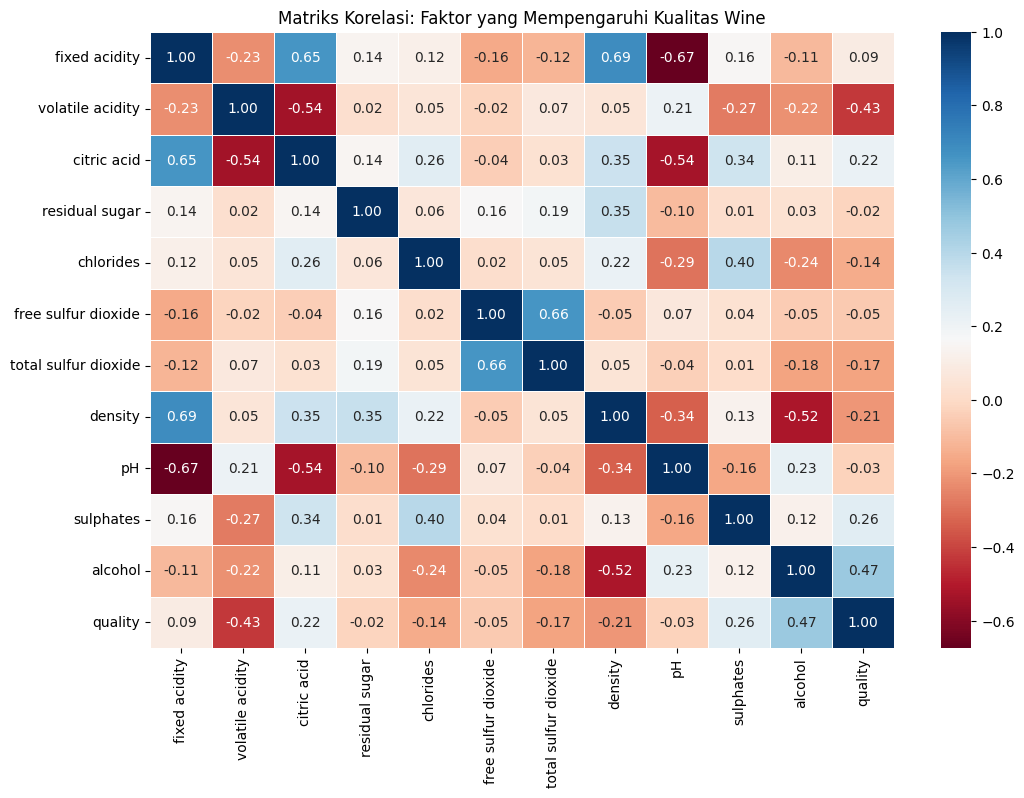


Korelasi variabel terhadap Quality (urut dari tertinggi):
quality                 1.000000
alcohol                 0.473555
sulphates               0.260703
citric acid             0.221263
fixed acidity           0.092714
residual sugar         -0.020511
pH                     -0.033199
free sulfur dioxide    -0.054509
chlorides              -0.144946
total sulfur dioxide   -0.172737
density                -0.207903
volatile acidity       -0.430059
Name: quality, dtype: float64


In [30]:
corr_matrix = df_train.drop(columns=['Id']).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt='.2f', linewidths=0.5)
plt.title('Matriks Korelasi: Faktor yang Mempengaruhi Kualitas Wine')
plt.show()

print("\nKorelasi variabel terhadap Quality (urut dari tertinggi):")
print(corr_matrix['quality'].sort_values(ascending=False))


*   Faktor Penentu Kualitas Positif: Kadar alkohol yang lebih tinggi merupakan prediktor positif terkuat terhadap kualitas anggur, diikuti oleh sulphates dan citric acid.
*   Faktor Penentu Kualitas Negatif: Volatile acidity yang tinggi merupakan prediktor negatif terkuat, yang menunjukkan bahwa anggur berkualitas rendah cenderung memiliki volatile acidityl yang lebih tinggi. Chlorides, total sulfur dioxide, dan denisty juga menunjukkan korelasi negatif dengan kualitas.



### **Cek Keseimbangan Data**

In [55]:
print("\nDistribusi Kelas Quality Asli:\n", df_train['quality'].value_counts())


Distribusi Kelas Quality Asli:
 quality
5    362
6    341
7    109
4     26
8     13
3      6
Name: count, dtype: int64


### **Distribusi Kelas Quality**
Menunjukkan frekuensi setiap nilai kualitas, yang kemungkinan besar akan menyoroti ketidakseimbangan kelas

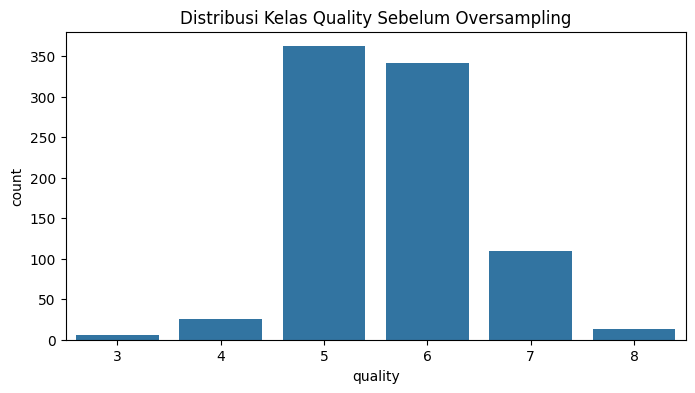

In [56]:
plt.figure(figsize=(8, 4))
sns.countplot(x='quality', data=df_train)
plt.title('Distribusi Kelas Quality Sebelum Oversampling')
plt.show()

### **Oversampling Manual**
Menyeimbangkan jumlah sampel di setiap kelas agar sesuai dengan jumlah kelas mayoritas. Setiap kelas yang jumlahnya kurang dari kelas mayoritas akan di resample (dengan penggantian) hingga mencapai jumlah sampel kelas mayoritas

In [33]:
# menyamakan jumlah setiap kelas dengan jumlah kelas mayoritas
max_size = df_train['quality'].value_counts().max()
lst = [df_train[df_train['quality'] == i] for i in df_train['quality'].unique()]
df_resampled = pd.DataFrame()

for class_index in lst:
    resampled_class = resample(class_index, replace=True, n_samples=max_size, random_state=42)
    df_resampled = pd.concat([df_resampled, resampled_class])

print(f"Jumlah data setelah oversampling: {len(df_resampled)}")

Jumlah data setelah oversampling: 2172


Output menunjukkan jumlah total data setelah oversampling yaitu 2172

### **Split Dataset**
Data dibagi menjadi set pelatihan (X_train, y_train) dan set validasi (X_val, y_val) dengan rasio 80:20

In [34]:
X = df_resampled.drop(columns=['Id', 'quality'])
y = df_resampled['quality']

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

### **Analisis Komparatif Model**
Membangun dan melatih dua model: RandomForestClassifier dan SVC (Support Vector Machine)

In [41]:
models = {"Random Forest": RandomForestClassifier(random_state=42), "SVM": SVC(kernel='rbf')}
results = {name: accuracy_score(y_val, m.fit(X_train, y_train).predict(X_val)) for name, m in models.items()}

### **Seleksi Model**
Memilih model terbaik berdasarkan akurasi yang diperoleh dari tahap komparatif

In [42]:
best_name = max(results, key=results.get)
print(f"\nModel Terbaik: {best_name} dengan Akurasi: {results[best_name]:.4f}")


Model Terbaik: Random Forest dengan Akurasi: 0.9586


Output menunjukkan Random Forest sebagai model terbaik dengan akurasi 0.9586

### **Uji Lanjutan (Hyperparameter Tuning)**
Dilakukan uji lanjutan yaitu hyperparameter tunning yang ditujukan untuk mencari parameter terbaik dari best model

In [43]:
param_grid = {'n_estimators': [200, 300], 'max_depth': [None, 30], 'criterion': ['gini', 'entropy']}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

### **Evaluasi Final**
Menggunakan best_model (hasil tuning) untuk membuat prediksi akhir pada set validasi

In [44]:
y_final_pred = best_model.predict(X_val)
print("\n--- Evaluasi Akhir ---")
print(f"Akurasi Final: {accuracy_score(y_val, y_final_pred):.4f}")
print(classification_report(y_val, y_final_pred))


--- Evaluasi Akhir ---
Akurasi Final: 0.9586
              precision    recall  f1-score   support

           3       1.00      1.00      1.00        66
           4       1.00      1.00      1.00        71
           5       0.87      0.92      0.90        75
           6       0.91      0.83      0.87        72
           7       0.97      1.00      0.99        76
           8       1.00      1.00      1.00        75

    accuracy                           0.96       435
   macro avg       0.96      0.96      0.96       435
weighted avg       0.96      0.96      0.96       435



 Output menunjukkan akurasi final 0.9586, serta presisi, recall, dan f1-score untuk setiap kelas kualitas

### **Prediksi Data Testing**
Menyiapkan data pengujian (df_test) dengan menghilangkan kolom Id dan menskalakannya menggunakan scaler

In [45]:
X_test_final = df_test.drop(columns=['Id'])
X_test_scaled = scaler.transform(X_test_final)
test_preds = best_model.predict(X_test_scaled)

In [52]:
submission = pd.DataFrame({'Id': df_test['Id'], 'quality': test_preds})
display(submission.head())

,Id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,7


DataFrame submission yang berisi kolom Id dari df_test dan hasil prediksi quality (test_preds)

In [54]:
from google.colab import files

nama_file = 'hasilprediksi_005.csv'
submission.to_csv(nama_file, index=False)
files.download(nama_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>